In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import datetime
import seaborn as sns

In [2]:
file_paths = [
    'NIFTY 50-25-07-2019-to-25-07-2020.csv',
    'NIFTY 50-25-07-2020-to-25-07-2021.csv',
    'NIFTY 50-25-07-2021-to-25-07-2022.csv',
    'NIFTY 50-25-07-2022-to-25-07-2023.csv',
    'NIFTY 50-25-07-2023-to-25-07-2024.csv']

dfs = [pd.read_csv(file) for file in file_paths]

data = pd.concat(dfs, ignore_index=True)

In [3]:
data=dfs[0]
data.rename(columns={"Date ":"Date"}, inplace=True)
data.head()    

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,25-JUL-2019,11290.40,11361.40,11239.35,11252.15,553676897,24329.21
1,26-JUL-2019,11247.45,11307.60,11210.05,11284.30,522670420,20350.38
2,29-JUL-2019,11307.50,11310.95,11152.40,11189.20,482862376,18705.92
3,30-JUL-2019,11213.70,11267.45,11072.65,11085.40,479059399,20545.71
4,31-JUL-2019,11034.05,11145.30,10999.40,11118.00,536694278,23681.22


In [4]:
data['Date'] = pd.to_datetime(data['Date'])

/var/folders/lk/6n2t4fms3356vvnxn6p17cmh0000gn/T/ipykernel_40350/1453708669.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


In [5]:
data.columns = ['Turnover' if col == 'Turnover (₹ Cr)' else col for col in data.columns]

# Display the DataFrame
print(data.head())

        Date     Open      High       Low     Close   Shares Traded   Turnover
0 2019-07-25  11290.40  11361.40  11239.35  11252.15       553676897  24329.21
1 2019-07-26  11247.45  11307.60  11210.05  11284.30       522670420  20350.38
2 2019-07-29  11307.50  11310.95  11152.40  11189.20       482862376  18705.92
3 2019-07-30  11213.70  11267.45  11072.65  11085.40       479059399  20545.71
4 2019-07-31  11034.05  11145.30  10999.40  11118.00       536694278  23681.22


In [6]:
data.columns=data.columns.str.strip()

In [7]:
print('Date'in data.columns)

True


In [8]:
data.columns


Index(['Date', 'Open', 'High', 'Low', 'Close', 'Shares Traded', 'Turnover'], dtype='object')

In [9]:
data.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Shares Traded    0
Turnover         0
dtype: int64

In [10]:
data.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover
0,2019-07-25,11290.40,11361.40,11239.35,11252.15,553676897,24329.21
1,2019-07-26,11247.45,11307.60,11210.05,11284.30,522670420,20350.38
2,2019-07-29,11307.50,11310.95,11152.40,11189.20,482862376,18705.92
3,2019-07-30,11213.70,11267.45,11072.65,11085.40,479059399,20545.71
4,2019-07-31,11034.05,11145.30,10999.40,11118.00,536694278,23681.22


In [11]:
data['Date'] = data['Date'].astype(str)


In [12]:
data['Date'] = data['Date'].str.replace('[- ]', '', regex=True)

In [13]:
data.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover
241,20200720,10999.45,11037.90,10953.00,11022.20,554306867,32738.64
242,20200721,11126.10,11179.55,11113.25,11162.25,771998838,42461.89
243,20200722,11231.20,11238.10,11056.55,11132.60,765074288,41068.72
244,20200723,11135.00,11239.80,11103.15,11215.45,621575333,32744.93
245,20200724,11149.95,11225.40,11090.30,11194.15,678935175,40217.17


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           246 non-null    object 
 1   Open           246 non-null    float64
 2   High           246 non-null    float64
 3   Low            246 non-null    float64
 4   Close          246 non-null    float64
 5   Shares Traded  246 non-null    int64  
 6   Turnover       246 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 13.6+ KB


In [15]:

data['Shares Traded'] = data['Shares Traded'].astype(float)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           246 non-null    object 
 1   Open           246 non-null    float64
 2   High           246 non-null    float64
 3   Low            246 non-null    float64
 4   Close          246 non-null    float64
 5   Shares Traded  246 non-null    float64
 6   Turnover       246 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.6+ KB


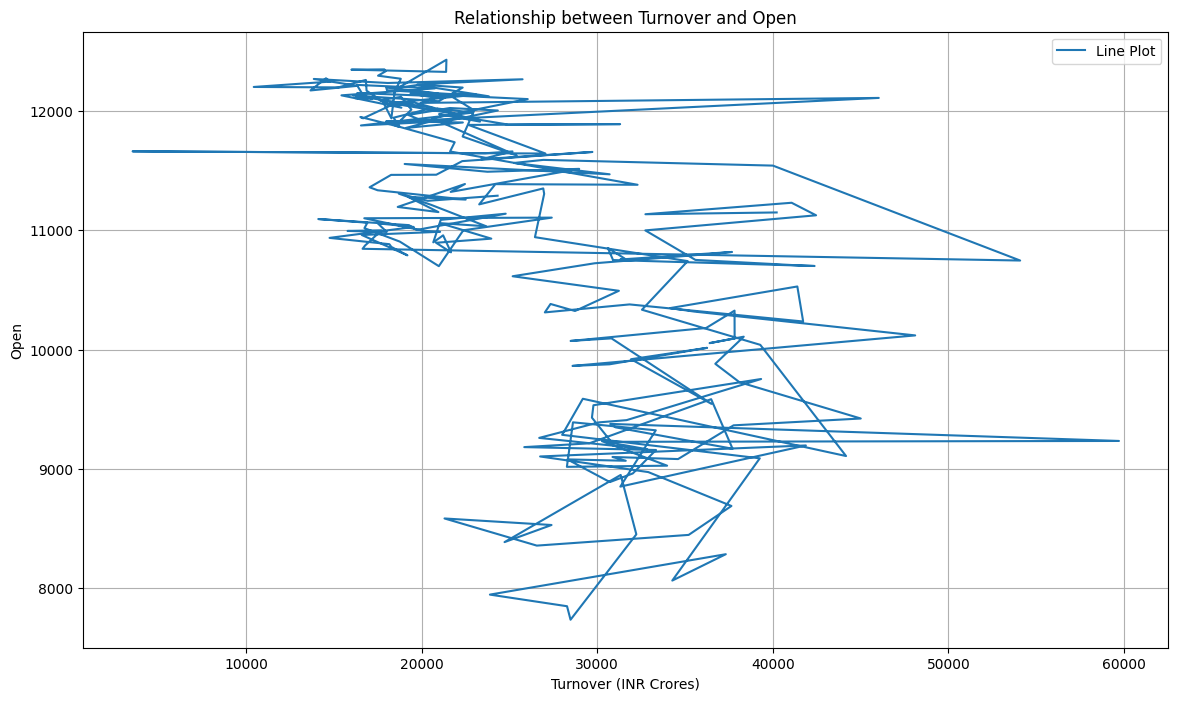

In [17]:
turnover = data['Turnover']
open_prices = data['Open']

# Create the plot
plt.figure(figsize=(14, 8))
plt.plot(turnover, open_prices, label='Line Plot')
plt.xlabel("Turnover (INR Crores)")
plt.ylabel('Open')
plt.title('Relationship between Turnover and Open')
plt.legend()
plt.grid(True)
plt.show()

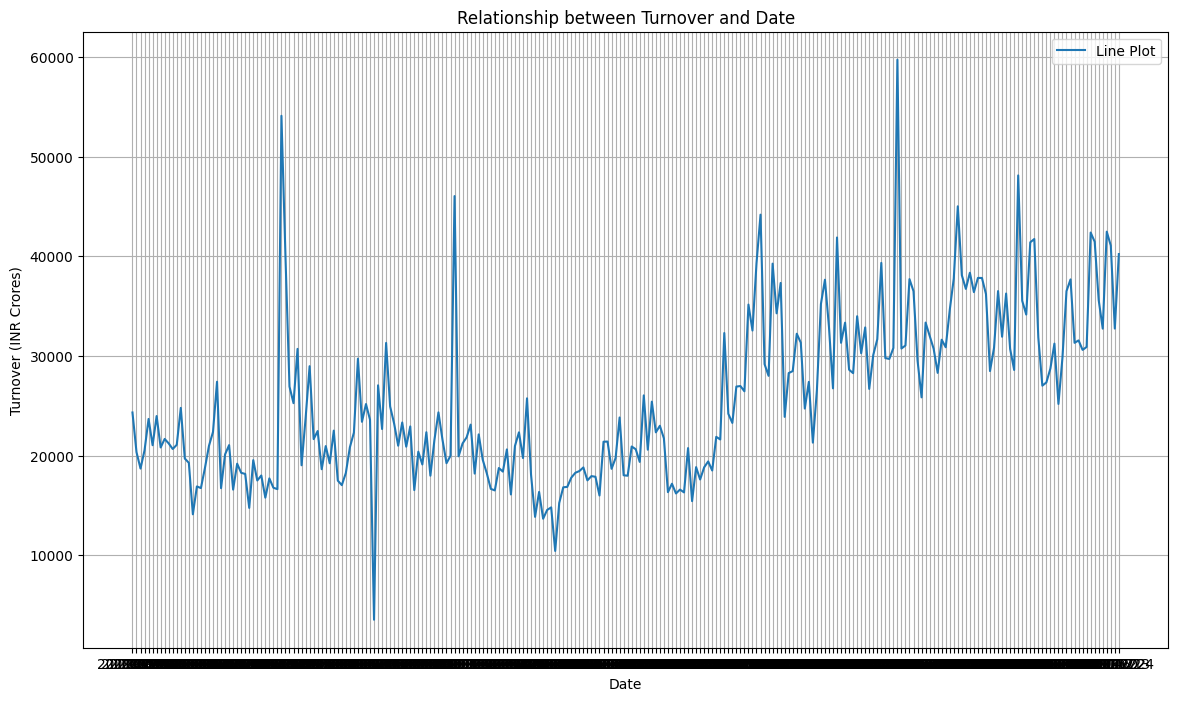

In [18]:
turnover = data['Turnover']
open_prices = data['Date']


 
 
# Create the plot
plt.figure(figsize=(14, 8))
plt.plot(open_prices, turnover, label='Line Plot')
plt.ylabel("Turnover (INR Crores)")
plt.xlabel('Date')
plt.title('Relationship between Turnover and Date')
plt.legend()
plt.grid(True)
plt.show()

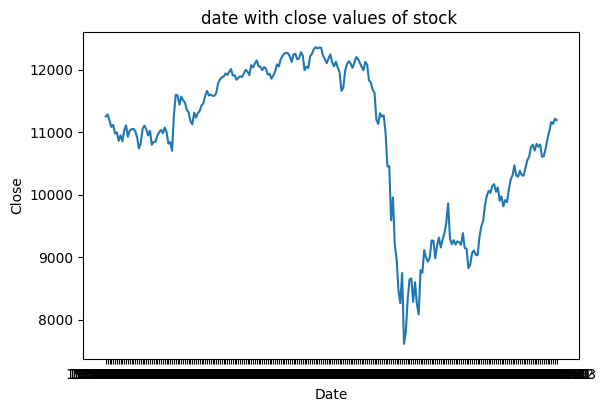

In [19]:
import matplotlib.dates as mdates
plt.gcf().autofmt_xdate()  # Automatically rotates the date labels to fit

# Set the date format on the x-axis
date_format = mdates.DateFormatter('%Y-%m-%d')
plt.gca().xaxis.set_major_formatter(date_format)

# Set labels and title
Date=data['Date']
Close=data['Close']
plt.plot(Date, Close, label='Line Plot')
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('date with close values of stock ')

# Show the plot
plt.show()

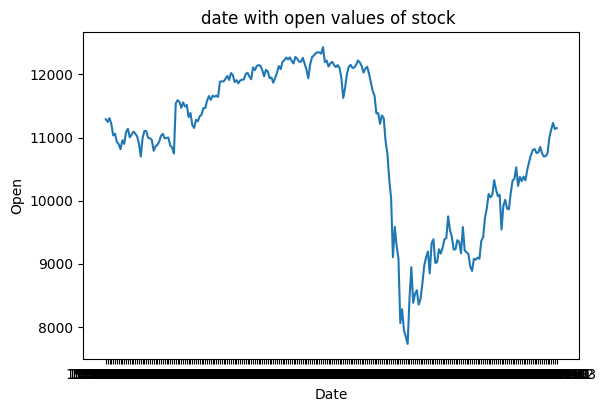

In [20]:
import matplotlib.dates as mdates
plt.gcf().autofmt_xdate()  # Automatically rotates the date labels to fit

# Set the date format on the x-axis
date_format = mdates.DateFormatter('%Y-%m-%d')
plt.gca().xaxis.set_major_formatter(date_format)

# Set labels and title
Date=data['Date']
Open=data['Open']
plt.plot(Date, Open, label='Line Plot')
plt.xlabel('Date')
plt.ylabel('Open')
plt.title('date with open values of stock ')

# Show the plot
plt.show()

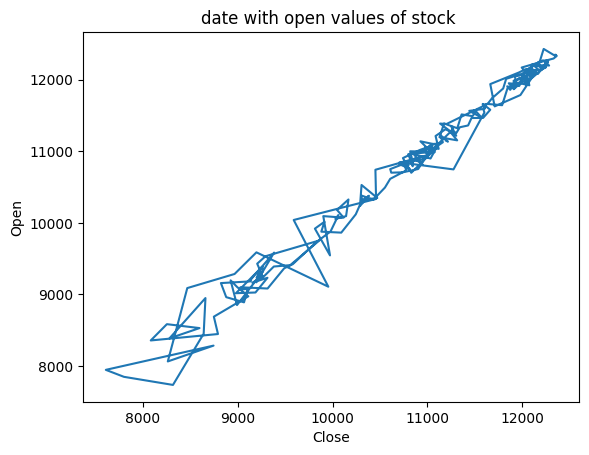

In [21]:
Date=data['Close']
Open=data['Open']
plt.plot(Close, Open, label='Line Plot')
plt.xlabel('Close')
plt.ylabel('Open')
plt.title('date with open values of stock ')

# Show the plot
plt.show()

In [22]:
import numpy as np
import pandas as pd

def systematic_sampling(data, sample_size):
    population_size = len(data)
    
    # Ensure sample size is not larger than the population size
    if sample_size >= population_size:
        raise ValueError("Sample size must be smaller than the population size.")
    
    interval = population_size // sample_size
    
    # Ensure interval is not zero
    if interval == 0:
        raise ValueError("Interval calculated as zero. Ensure population size is much larger than sample size.")
    
    start = np.random.randint(0, interval)
    
    indices = [i for i in range(start, population_size, interval)]
    sampled_df = data.iloc[indices]
    return sampled_df

In [23]:
sample_size = 100

# Take samples using systematic sampling
sampled_df = systematic_sampling(data, sample_size)

print("Sampled DataFrame:")
sampled_df

Sampled DataFrame:


,Date,Open,High,Low,Close,Shares Traded,Turnover
1,20190726,11247.45,11307.60,11210.05,11284.30,522670420.0,20350.38
3,20190730,11213.70,11267.45,11072.65,11085.40,479059399.0,20545.71
5,20190801,11060.20,11076.75,10881.00,10980.00,499918953.0,21048.32
7,20190805,10895.80,10895.80,10782.60,10862.60,506556609.0,20824.10
9,20190807,10958.10,10975.65,10835.90,10855.50,548465787.0,21228.28
...,...,...,...,...,...,...,...
237,20200714,10750.85,10755.65,10562.90,10607.35,532368699.0,30902.47
239,20200716,10706.20,10755.30,10595.20,10739.95,694402635.0,41453.95
241,20200720,10999.45,11037.90,10953.00,11022.20,554306867.0,32738.64
243,20200722,11231.20,11238.10,11056.55,11132.60,765074288.0,41068.72


In [24]:
sampled_df.describe()

,Open,High,Low,Close,Shares Traded,Turnover
count,123.000000,123.000000,123.000000,123.000000,1.230000e+02,123.000000
mean,10914.222764,10989.648374,10813.432927,10900.308943,6.821011e+08,25685.262520
std,1168.696908,1130.083296,1218.293728,1175.095688,2.252944e+08,8141.611803
min,7848.300000,8036.950000,7511.100000,7801.050000,3.040780e+08,10445.680000
25%,10063.425000,10136.300000,9990.550000,10103.900000,5.329186e+08,19327.675000
50%,11106.550000,11225.400000,11056.550000,11109.650000,6.230498e+08,23281.200000
75%,11963.125000,12020.375000,11897.050000,11951.700000,7.707356e+08,31431.155000
max,12349.400000,12385.450000,12321.400000,12352.350000,1.566119e+09,54081.530000


In [25]:
data.describe()

,Open,High,Low,Close,Shares Traded,Turnover
count,246.000000,246.000000,246.000000,246.000000,2.460000e+02,246.000000
mean,10915.965447,10994.825813,10813.196341,10902.379065,6.763559e+08,25621.130610
std,1176.382597,1129.573506,1216.688571,1173.566891,2.175851e+08,8356.944938
min,7735.150000,8036.950000,7511.100000,7610.250000,1.617790e+08,3548.210000
25%,10097.650000,10176.600000,10035.875000,10097.775000,5.348907e+08,19056.420000
50%,11116.325000,11180.500000,11043.675000,11113.825000,6.396821e+08,23303.085000
75%,11963.100000,12016.150000,11888.825000,11956.900000,7.577366e+08,31188.495000
max,12430.500000,12430.500000,12321.400000,12362.300000,1.811564e+09,59705.530000


<Axes: >

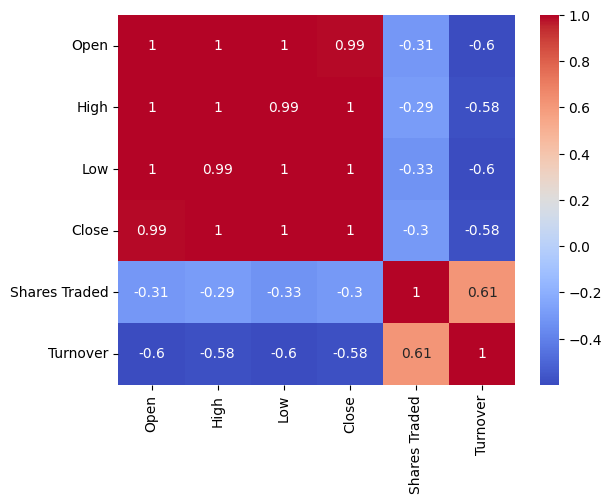

In [26]:
plt.figure()
sns.heatmap(data.select_dtypes("number").corr(), annot=True, cmap='coolwarm')

<Axes: >

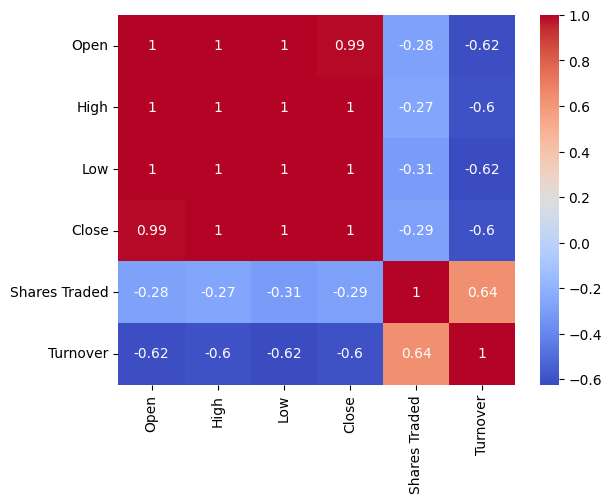

In [27]:
plt.figure()
sns.heatmap(sampled_df.select_dtypes("number").corr(), annot=True, cmap='coolwarm')

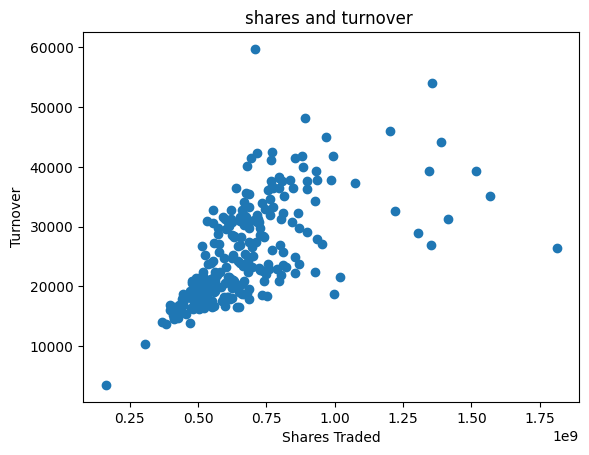

In [28]:
Share=data['Shares Traded']
Turnover=data['Turnover']
plt.scatter(Share, Turnover, label='Dot')
plt.xlabel('Shares Traded')
plt.ylabel('Turnover')
plt.title('shares and turnover ')

# Show the plot
plt.show()

# forecasting steps 


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
result = adfuller(data['Close'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


#as the threshold value is 0.05 then this test suggest that our data is not stationary 

ADF Statistic: -1.605190
p-value: 0.480986


In [31]:
# perfoming log transformation for converting our non stationary data into stationary 
# Log transform
data['Close_log'] = np.log(data['Close'])

# First difference of the log-transformed data
data['Close_log_diff'] = data['Close_log'] - data['Close_log'].shift(1)

# Drop the NaN values that are created by the shift operation
data.dropna(inplace=True)

# Check the result
print(data[['Close', 'Close_log', 'Close_log_diff']].head())

# Perform the ADF test again on the log differenced data
result = adfuller(data['Close_log_diff'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


     Close  Close_log  Close_log_diff
1  11284.3   9.331168        0.002853
2  11189.2   9.322704       -0.008463
3  11085.4   9.313384       -0.009320
4  11118.0   9.316321        0.002936
5  10980.0   9.303831       -0.012490
ADF Statistic: -4.579478
p-value: 0.000141


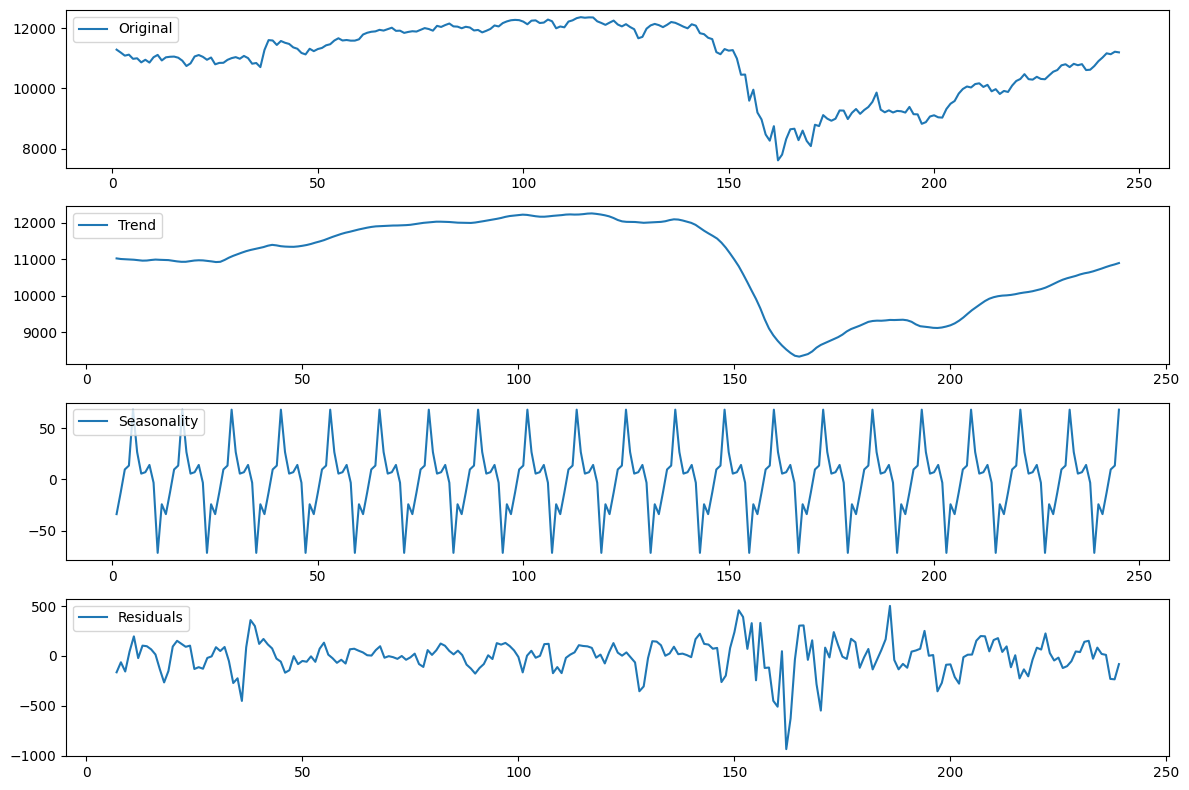

In [32]:
#performing additive decomposition for removing the sesonal and residual components 
result = seasonal_decompose(data['Close'], model='additive', period=12)  # Assuming seasonality period is 12 (monthly data)

# Plot the decomposed components
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(data['Close'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(result.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonality')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(result.resid, label='Residuals')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

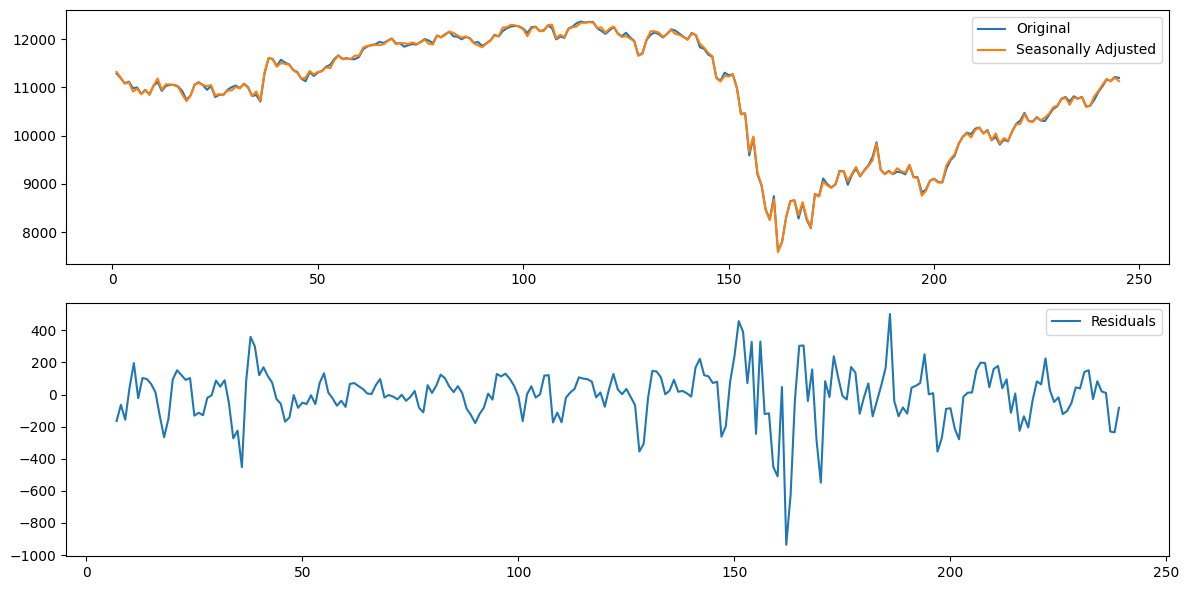

In [33]:
# Handle seasonal component
seasonally_adjusted = data['Close'] - result.seasonal

# Handle residual component
residuals = result.resid

# Further analysis or visualization of components
# For example, plotting the seasonally adjusted series and residuals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(data['Close'], label='Original')
plt.plot(seasonally_adjusted, label='Seasonally Adjusted')
plt.legend()

plt.subplot(212)
plt.plot(residuals, label='Residuals')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Extracting 'Close' prices from the DataFrame
close_prices = data['Close'].dropna()


In [ ]:
# Applying simple exponential smoothing
model = ExponentialSmoothing(close_prices)
result = model.fit()


/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [36]:
smoothed_values = result.fittedvalues


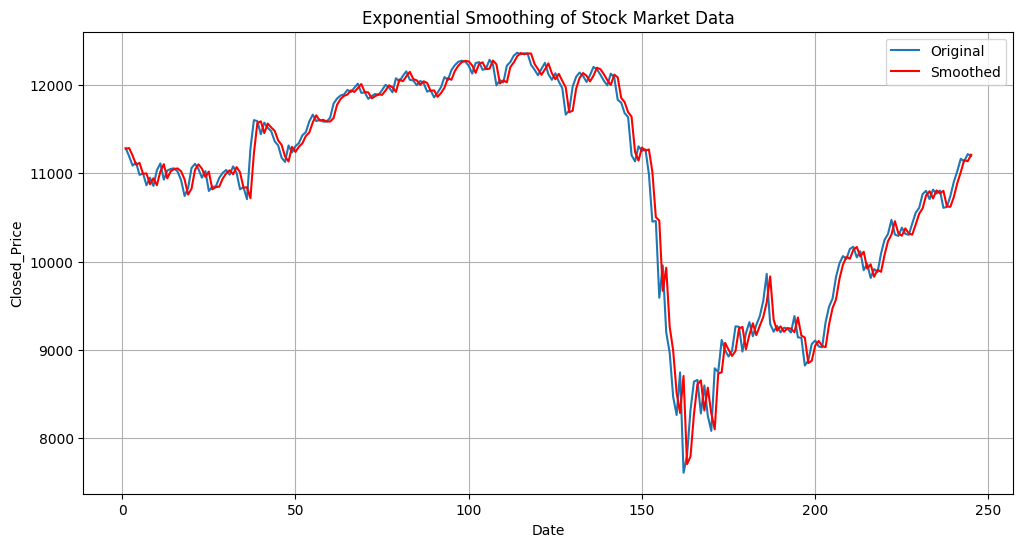

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label='Original')
plt.plot(smoothed_values, label='Smoothed', color='red')
plt.title('Exponential Smoothing of Stock Market Data')
plt.xlabel('Date')
plt.ylabel('Closed_Price')
plt.legend()
plt.grid(True)
plt.show()


In [38]:
# Extract the closing prices
close_prices = data['Close']

In [39]:
# Applying Holt-Winters Exponential Smoothing
hw_model = ExponentialSmoothing(close_prices, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit()

# Extract the fitted values
fitted_values = hw_fit.fittedvalues

/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


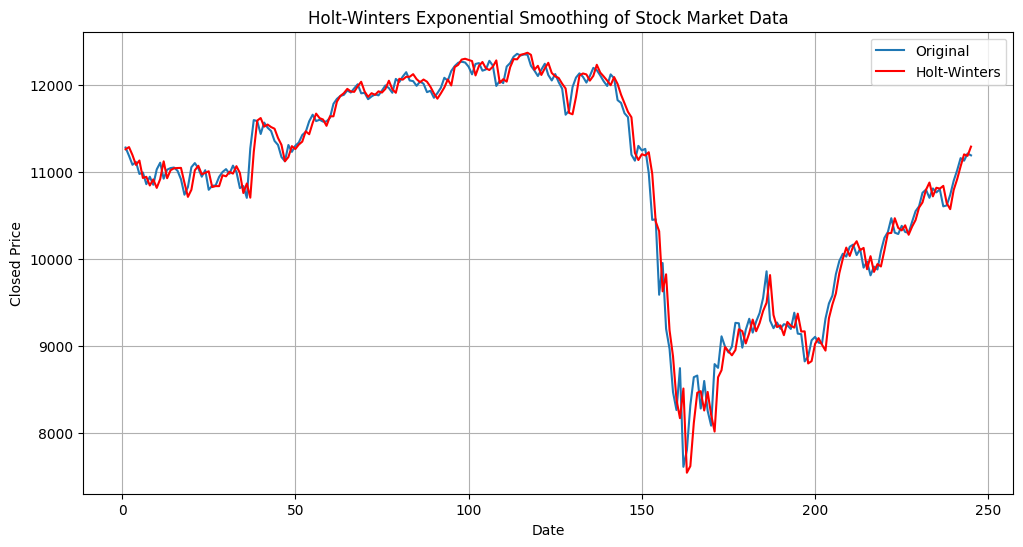

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label='Original')
plt.plot(fitted_values, label='Holt-Winters', color='red')
plt.title('Holt-Winters Exponential Smoothing of Stock Market Data')
plt.xlabel('Date')
plt.ylabel('Closed Price')
plt.legend()
plt.grid(True)
plt.show()

# used for double triple smoothning of the data so as to analyze the trend more accurately 

<Figure size 1200x600 with 0 Axes>

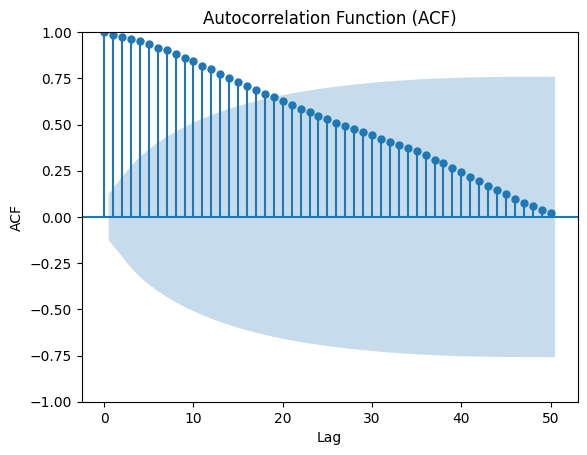

<Figure size 1200x600 with 0 Axes>

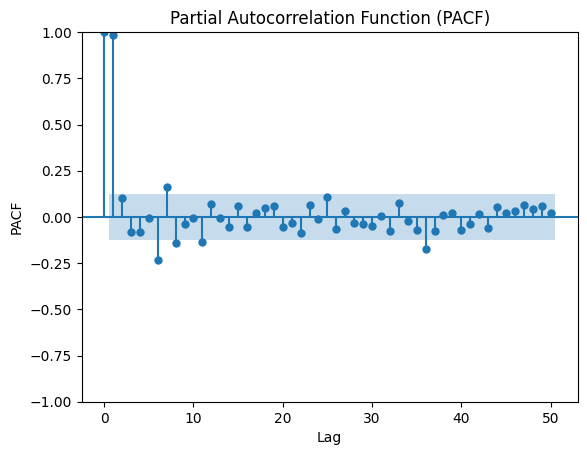

In [41]:
#ACF and PACF for know what model is to get applied 

# Plot ACF
plt.figure(figsize=(12, 6))
plot_acf(close_prices, lags=50, title='Autocorrelation Function (ACF)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.show()

# Plot PACF
plt.figure(figsize=(12, 6))
plot_pacf(close_prices, lags=50, title='Partial Autocorrelation Function (PACF)')
plt.xlabel('Lag')
plt.ylabel('PACF')
plt.show()

# as the acf is suggesting a trailing edge and the pacf is suggesting an immediate drop so the model we will use 
#for better understanding will be auto regressive 

In [42]:
#plotting ARIMA model 

# Example: Fit ARIMA(1, 1, 1) model
model = ARIMA(close_prices, order=(1, 1, 1))
result = model.fit()

# Print model summary
result.summary()


/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generat

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  245
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1623.755
Date:                Wed, 03 Sep 2025   AIC                           3253.509
Time:                        19:45:37   BIC                           3264.001
Sample:                             0   HQIC                          3257.735
                                - 245                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3412      0.234     -1.455      0.146      -0.801       0.118
ma.L1          0.2300      0.251      0.915      0.360      -0.263       0.723
sigma2       3.53e+04   1705.512     20.698      0.000     3.2e+04    3.86e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               596.76
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               2.46   Skew:                            -1.16
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


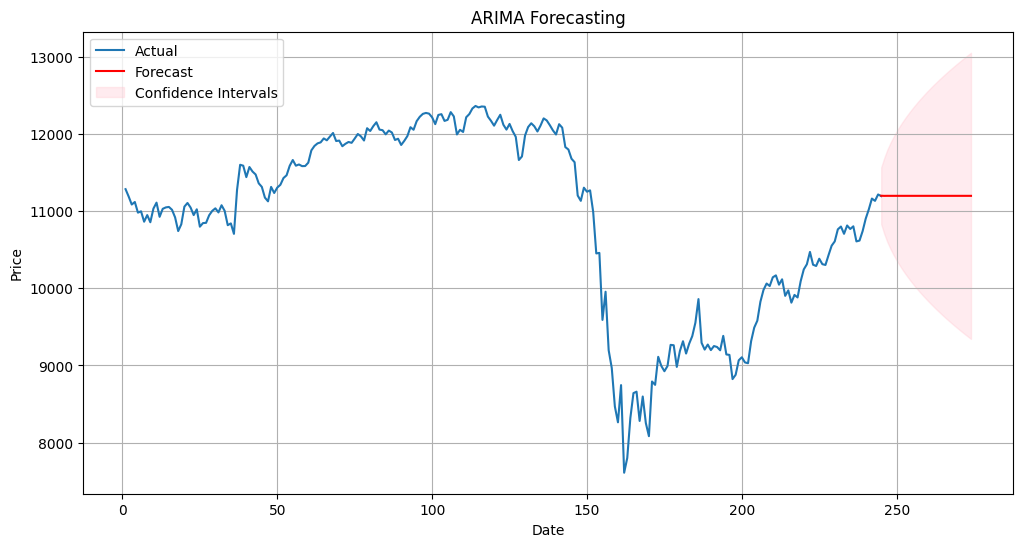

In [43]:
# Forecast future values
forecast_steps = 30  # Number of steps ahead to forecast
forecast = result.get_forecast(steps=forecast_steps)

# Extract forecasted values and confidence intervals
forecast_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# Plotting forecasts
plt.figure(figsize=(12, 6))
plt.plot(close_prices, label='Actual')
plt.plot(forecast_values.index, forecast_values.values, color='red', label='Forecast')
plt.fill_between(confidence_intervals.index, confidence_intervals.iloc[:, 0], confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Intervals')
plt.title('ARIMA Forecasting')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

 # Replace with your actual observed values for the forecast period
y_true = np.array(data['Close'][-30:])
y_pred = np.array(forecast_values)  # Using forecasted values from ARIMA model

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

Mean Absolute Error (MAE): 627.12
Mean Squared Error (MSE): 535644.36
Root Mean Squared Error (RMSE): 731.88
Mean Absolute Percentage Error (MAPE): 6.07%


In [46]:
mape = np.mean(np.abs((y_true - forecast_values) / y_true)) * 100

# Calculate accuracy percentage
accuracy_percentage = 100 - mape

print(f'Percentage Accuracy: {accuracy_percentage:.2f}%')

Percentage Accuracy: 93.93%
